# **KLASYFIKATOR WYMIANY BANKNOTÓW**

**Jakub B.**


Projekt ma na celu stworzenie aplikacji, która sprawdza stan banknotów na podstawie dostarczonych zdjęć.

Działanie aplikacji:
1. Użytkownik wczytuje przód i tył uszkodzonego banknotu.
2. Aplikacja wykrywa krawędzie i oblicza pole powierzchni każdego fragmentu uszkodzonego banknotu, następnie największy zachowany fragment porównuje do pola oryginalnego nieuszkodzonego banknotu.
3. Aplikacja wykrywa jaki nominał ma banknot wczytany przez użytkownika. Następnie użytkownik otrzymuje informacje o polach poszczególnych fragmentów, o polu oryginalnego banknotu, stosunku procentowym największego zachowanego fragmentu do banknotu oryginalnego oraz informacje na ile fragmentów banknot jest podzielony.
4. Aplikacja wykrywa różnice pomiędzy wczytanym zdjęciem banknotu uszkodzonego, a zdjęciem oryginalnym i pokazuje, które miejsca mają uszkodzenia.
5. Aplikacja wyświetla ponownie przód i tył banknotu wczytanego przez użytkownika, następnie wyświetla kontury wszystkich fragmentów tego banknotu oraz różnice w porównaniu z banknotem oryginalnym. Użytkownik otrzymuje również informację o polu największego fragementu, o stosunku procentowym do oryginalnego banknotu, o ilości fragementów banknotu oraz czy banknot zostanie wymieniony i na jaką kwotę.
6. Aplikacja na końcu umożliwia wyczyszczenie wgranych zdjęć z pamięci.

Na potrzeby aplikacji użyte banknoty zostały pobrane ze strony https://www.realbanknotes.com

# **SPIS TREŚCI**
1. IMPORTOWANIE BIBLIOTEK
2. WCZYTANIE PRZODU I TYŁU BANKNOTU
3. WYKRYWANIE KRAWĘDZI
4. WYKRYWANIE NOMINAŁU
5. WYKRYWANIE RÓŻNIC
6. KWALIFIKACJA BANKNOTU
7. CZYSZCZENIE PLIKÓW Z PAMIĘCI APLIKACJI

**ZASADY WYMIANY BANKNOTÓW**
*   Banknot zostanie wymieniony jeśli więcej niż 45% jego pierwotnej powierzchni zachowało się w jednym fragmencie i jeśli można rozpoznać jaki to nominał
*   Banknot, który zachował się od 45% do 75% pierwotnej powierzchni w jednym fragmencie, zostanie wymieniony za połowę jego wartości
*   Banknot, który zachował ponad 75% pierwotnej powierzchni w jednym fragmencie, zostanie wymieniony na pełną wartość
*   Banknot przerwany na nie więcej niż dziewięć części stanowiący w całości 100% jego pierwotnej powierzchni, zostanie wymieniony na pełną wartość (jeżeli wszystkie części pochodzą z tego samego banknotu, nie posiadają ubytków powierzchni w miejscu przerwania i łącznie stanowią 100% pierwotnej powierzchni)
*   Zabrudzenia, o ile nie utrudniają czytelności banknotu, nie wpływają na jego wymianę. W przypadku, gdy zabrudzenia są bardzo poważne i uniemożliwiają identyfikację nominału kierowane są do szczegółowej ekspertyzy.




# IMPORTOWANIE BIBLIOTEK

- from google.colab import files
  - biblioteka używana do eksportowania plików z komputera
- from google.colab.patches import cv2_imshow
  - biblioteka używana do wyświetlania obrazów poprzez OpenCV (patch, który to umożliwia)
- from PIL import Image, ImageFilter
  - biblioteka używana do otwierania obrazów wgranych przez użytkownika
- from io import BytesIO
  - biblioteka używana do operacji na zdjęciach w pamięci
- import matplotlib.pyplot as plt
  - biblioteka używana do wyświetlania obrazów
- import cv2
  - biblioteka wykorzystywana do różnych operacji na obrazach m.in. cv2.cvtColor(), cv2.resize(), cv2.medianBlur() itp.
- import numpy as np
  - biblioteka używana do operacji na tablicach m.in. np.array(), np.ones() itp.
- import os
  - biblioteka używana do listowania i usuwania plików z aplikacji

In [ ]:
from google.colab import files
from google.colab.patches import cv2_imshow
from PIL import Image, ImageFilter
from io import BytesIO
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

# WCZYTANIE PRZODU I TYŁU BANKNOTÓW

Witaj w klasyfikatorze banknotów.
Pomogę Ci zidentyfikować, czy twój banknot podlega wymianie.
Wybierz zdjęcie przodu banknotu.


Saving 6.png to 6.png
Zdjęcie '6.png' ma rozmiar 600x295


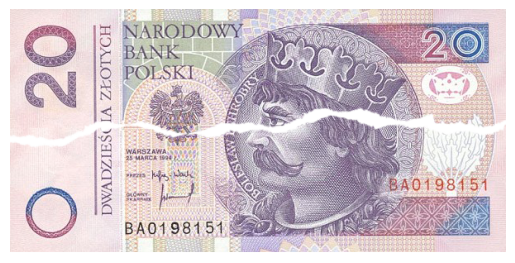

Zdjęcie zostało poprawnie załadowane.
Wybierz zdjęcie tyłu banknotu.


Saving 6.1.png to 6.1.png
Zdjęcie '6.1.png' ma rozmiar 600x295


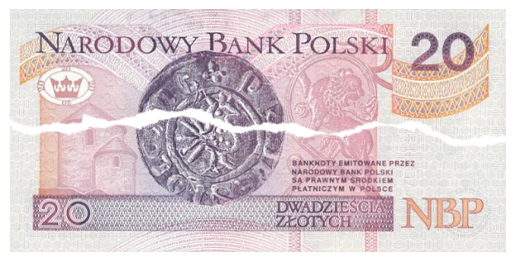

Zdjęcie zostało poprawnie załadowane.


In [ ]:
def upload_banknotes():
    print("Witaj w klasyfikatorze banknotów.")
    print("Pomogę Ci zidentyfikować, czy twój banknot podlega wymianie.")

# Funkcja, która pozwala na przesłanie plików przez użytkownika bezpośrednio z komputera.

    def display(prompt):
        print(prompt)
        uploaded = files.upload()

        if not uploaded:
            print("Brak pliku. Spróbuj ponownie.")
            return None, None

        file_name = list(uploaded.keys())[0]
        file_content = uploaded[file_name]

        try:
            banknote = Image.open(BytesIO(file_content))
            size = banknote.size
            print(f"Zdjęcie '{file_name}' ma rozmiar {size[0]}x{size[1]}")
            plt.imshow(banknote)
            plt.axis('off')
            plt.show()
            return banknote, size

        except Exception as e:
            print(f"Wystąpił błąd podczas ładowania zdjęcia: {e}")
            return None, None

    global front, back

    front, front_size = display("Wybierz zdjęcie przodu banknotu.")

    if front is None:
        print("Nie udało się załadować zdjęcia")
    else:
        print("Zdjęcie zostało poprawnie załadowane.")

    back, back_size = display("Wybierz zdjęcie tyłu banknotu.")

    if back is None:
        print("Nie udało się załadować zdjęcia")
    else:
        print("Zdjęcie zostało poprawnie załadowane.")

upload_banknotes()

# WYKRYWANIE KRAWĘDZI

In [ ]:
def detect_edges(result):
    global front, back, output_front_rgb, output_back_rgb, original_area, max_area, num_parts

    original_path = f'banknot_{result}.png'

    try:
        original = Image.open(original_path)
    except FileNotFoundError:
        print(f"Nie znaleziono pliku o nazwie: {original_path}.")
        return

    if front is None or back is None:
        print("Brak wczytanych obrazów. Spróbuj wczytać ponownie.")
        return

# Konwertowanie obrazów PIL na OpenCV.

    img_front = cv2.cvtColor(np.array(front), cv2.COLOR_RGBA2BGRA)
    img_back = cv2.cvtColor(np.array(back), cv2.COLOR_RGBA2BGRA)
    img_original = cv2.cvtColor(np.array(original), cv2.COLOR_RGBA2BGRA)

# Dopasowanie rozmiarów obrazów do oryginalnego.

    img_front = cv2.resize(img_front, (img_original.shape[1], img_original.shape[0]))
    img_back = cv2.resize(img_back, (img_original.shape[1], img_original.shape[0]))

# Ekstraktowanie kanału alpha.

    alpha_front = img_front[:, :, 3]
    alpha_back = img_back[:, :, 3]
    alpha_original = img_original[:, :, 3]

# Redukowanie szumów za pomocą Median Blur.

    blur_front = cv2.medianBlur(alpha_front, 5)
    blur_back = cv2.medianBlur(alpha_back, 5)
    blur_original = cv2.medianBlur(alpha_original,5)

# Definiowanie zakresu kolorów.

    lower_color = np.array([0, 0, 0, 255])
    upper_color = np.array([255, 255, 255, 255])

# Utworzenie masek.

    mask_front = cv2.inRange(img_front, lower_color, upper_color)
    mask_back = cv2.inRange(img_back, lower_color, upper_color)
    mask_original = cv2.inRange(img_original, lower_color, upper_color)

# Morfologia - closing - wypełnienie małych dziur w białych obszarach.

    kernel = np.ones((3, 3), np.uint8)
    mask_front = cv2.morphologyEx(mask_front, cv2.MORPH_CLOSE, kernel, iterations=1)
    mask_back = cv2.morphologyEx(mask_back, cv2.MORPH_CLOSE, kernel, iterations=1)
    mask_original = cv2.morphologyEx(mask_original, cv2.MORPH_CLOSE, kernel, iterations=1)

# Wykrywanie konturów.

    contours_front, _ = cv2.findContours(mask_front, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_back, _ = cv2.findContours(mask_back, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_original, _ = cv2.findContours(mask_original, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filtrowanie według powierzchni.

    min_area = 1000
    contours_front = [c for c in contours_front if cv2.contourArea(c) > min_area]
    contours_back = [c for c in contours_back if cv2.contourArea(c) > min_area]
    contours_original = [c for c in contours_original if cv2.contourArea(c) > min_area]

# Rysowanie konturów i obliczanie powierzchni.

    output_front = img_front.copy()
    output_back = img_back.copy()
    output_original = img_original.copy()

    colors = [(255, 0, 0, 255), (0, 255, 0, 255), (0, 0, 255, 255), (255, 255, 0, 255), (255, 0, 255, 255)]

    num_parts = 0
    max_area = 0

    for i, contour in enumerate(contours_front):
        area = cv2.contourArea(contour)
        if area > 0:
            cv2.drawContours(output_front, [contour], -1, colors[i % len(colors)], 2)
            print(f"Pole konturu {i+1}: {area}")
            num_parts += 1
            if area > max_area:
                max_area = area

    for i, contour in enumerate(contours_back):
        area = cv2.contourArea(contour)
        if area > 0:
            cv2.drawContours(output_back, [contour], -1, colors[i % len(colors)], 2)

# Wyświetlanie informacji o powierzchni.

    if len(contours_original) > 0:
        original_area = cv2.contourArea(contours_original[0])
        print(f"Powierzchnia oryginalnego banknotu: {original_area}")
        if original_area > 0:
            percentage = (max_area / original_area) * 100
            print(f"Stosunek największego pola do pola oryginalnego banknotu: {percentage:.2f}%")
        else:
            print("Powierzchnia oryginalnego banknotu wynosi 0, nie można obliczyć stosunku procentowego.")
    else:
        print("Nie znaleziono konturów na oryginalnym banknocie.")

# Konwertowanie obrazów na format RGB.

    output_front_rgb = cv2.cvtColor(output_front, cv2.COLOR_BGRA2RGBA)
    output_back_rgb = cv2.cvtColor(output_back, cv2.COLOR_BGRA2RGBA)
    output_original_rgb = cv2.cvtColor(output_original, cv2.COLOR_BGRA2RGBA)

# Wyświetlenie liczby fragmentów.

    if num_parts > 1:
        print(f"Banknot podzielony jest na {num_parts} części.")
    else:
        print(f"Banknot jest w {num_parts} fragmencie")

# Wyświetlenie wyników.

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(output_front_rgb)
    plt.title("Przód banknotu z zaznaczonymi konturami")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(output_back_rgb)
    plt.title("Tył banknotu z zaznaczonymi konturami")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# WYKRYWANIE NOMINAŁU

Rozpoznany banknot: 20 PLN
Pole konturu 1: 86372.0
Pole konturu 2: 81491.0
Powierzchnia oryginalnego banknotu: 176106.0
Stosunek największego pola do pola oryginalnego banknotu: 49.05%
Banknot podzielony jest na 2 części.


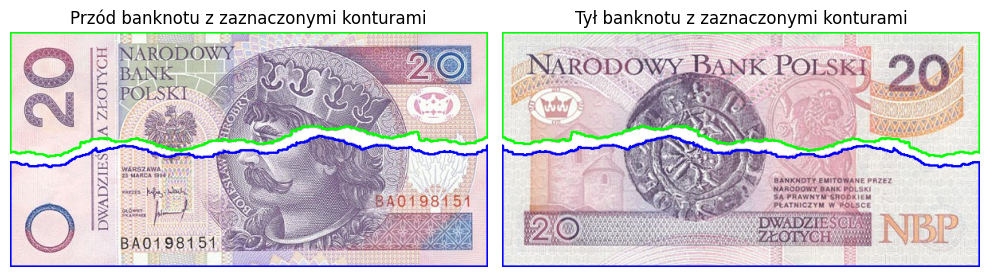

In [ ]:
global front

# Wczytanie oryginalnych zdjęć banknotów.

banknotes = {
    "10": cv2.imread("banknot_10.png", 0),
    "20": cv2.imread("banknot_20.png", 0),
    "50": cv2.imread("banknot_50.png", 0),
    "100": cv2.imread("banknot_100.png", 0),
    "200": cv2.imread("banknot_200.png", 0)
}

test_image = np.array(front)

def detect_banknotes(test_image, banknotes):

  # Utworzenie detektora ORB (Oriented FAST and Rotated BRIEF).
    detector = cv2.ORB_create()

  # Wykrywanie cech i deskryptorów dla obrazu testowego.
    test_keypoints, test_descriptors = detector.detectAndCompute(test_image, None)

  # Utworzenie dopasowywacza cech.
    descriptor_matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    max_matches = 0
    detected_note = None

    for note, image in banknotes.items():

      # Wykrywanie cech i deskryptorów dla banknotów.
        banknote_keypoints, banknote_descriptors = detector.detectAndCompute(image, None)

      # Dopasowanie deskryptorów.
        matches = descriptor_matcher.match(test_descriptors, banknote_descriptors)
        matches = sorted(matches, key=lambda x: x.distance)

        if len(matches) > max_matches:
            max_matches = len(matches)
            detected_note = note

    return detected_note

result = detect_banknotes(test_image, banknotes)
print(f"Rozpoznany banknot: {result} PLN")
detect_edges(result)

# WYKRYWANIE RÓŻNIC

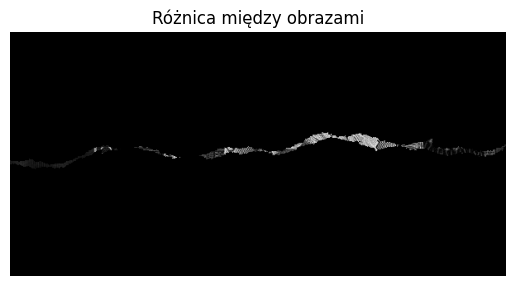

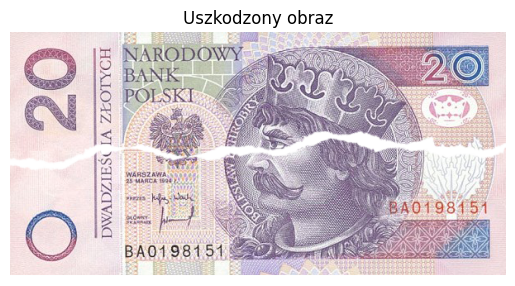

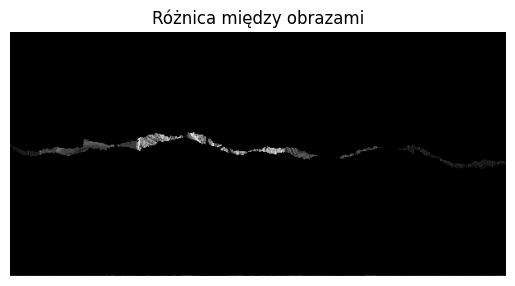

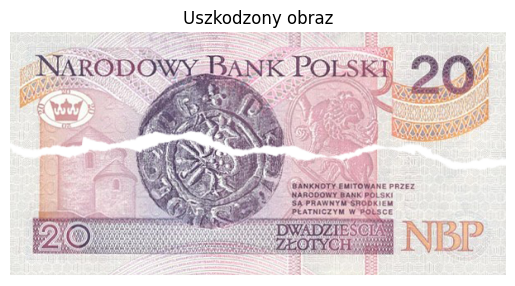

In [ ]:
global front, back

def find_difference(original, comparison, is_front):

    global diff_normalized_front, diff_normalized_back

    gray_original = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    comparison_np = np.array(comparison)
    gray_comparison = cv2.cvtColor(comparison_np, cv2.COLOR_RGB2GRAY)

  # Obliczanie różnicy między banknotem oryginalnym, a uszkodzonym.
    diff = cv2.absdiff(gray_original, gray_comparison)

  # Normalizacja różnicy obrazów do zakresu 0-255.
    diff_normalized = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX)

    if is_front:
        diff_normalized_front = diff_normalized
    else:
        diff_normalized_back = diff_normalized


    plt.imshow(diff_normalized, cmap='gray')
    plt.title("Różnica między obrazami")
    plt.axis('off')
    plt.show()

    plt.imshow(comparison)
    plt.title("Uszkodzony obraz")
    plt.axis('off')
    plt.show()

# Wczytywanie oryginalnych banknotów na podstawie nominału potwierdzonego przez użytkownika.
if result == '10':
    original_front = cv2.imread('banknot_10.png')
    original_back = cv2.imread('banknot_10_tyl.png')
elif result == '20':
    original_front = cv2.imread('banknot_20.png')
    original_back = cv2.imread('banknot_20_tyl.png')
elif result == '50':
    original_front = cv2.imread('banknot_50.png')
    original_back = cv2.imread('banknot_50_tyl.png')
elif result == '100':
    original_front = cv2.imread('banknot_100.png')
    original_back = cv2.imread('banknot_100_tyl.png')
elif result == '200':
    original_front = cv2.imread('banknot_200.png')
    original_back = cv2.imread('banknot_200_tyl.png')

if original_front is None or original_back is None:
    print("Nie udało się załadować zdjęcia")
else:
    if front is not None:
        find_difference(original_front, front, True)
    if back is not None:
        find_difference(original_back, back, False)

# KWALIFIKACJA BANKNOTU

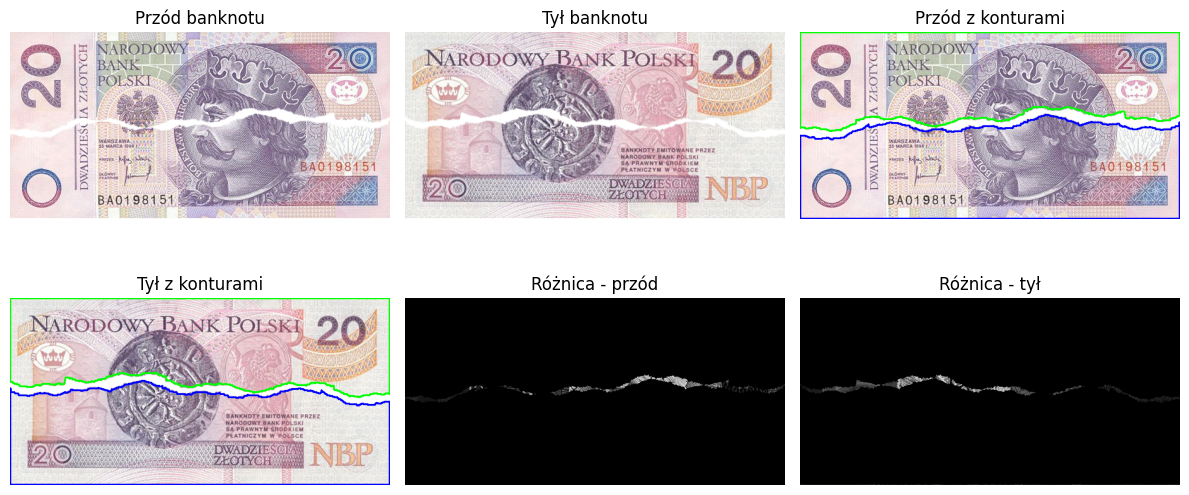

Pole największego konturu: 86372.0, Stosunek procentowy: 49.05%
Banknot podzielony jest na 2 części.
Banknot najprawdopodobniej zostanie wymieniony za połowę ceny.


In [ ]:
global front, back, output_front_rgb, output_back_rgb

def qualification():

    global diff_normalized_front, diff_normalized_back

    plt.figure(figsize=(12, 6))

    plt.subplot(2, 3, 1)
    plt.imshow(front)
    plt.title("Przód banknotu")
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(back)
    plt.title("Tył banknotu")
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(output_front_rgb)
    plt.title("Przód z konturami")
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(output_back_rgb)
    plt.title("Tył z konturami")
    plt.axis('off')

    plt.subplot(2, 3, 5)

    if diff_normalized_front is not None:
        diff_normalized_front = np.asarray(diff_normalized_front)

    plt.imshow(diff_normalized_front, cmap='gray')
    plt.title("Różnica - przód")
    plt.axis('off')

    plt.subplot(2, 3, 6)

    if diff_normalized_back is not None:
        diff_normalized_back = np.asarray(diff_normalized_back)
        plt.imshow(diff_normalized_back, cmap='gray')
        plt.title("Różnica - tył")
        plt.axis('off')
    else:

        plt.text(0.5, 0.5, "Brak obrazu różnicy dla tyłu", ha='center', va='center')
        plt.title("Różnica - tył")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    global original_area, max_area, num_parts

# Wyświetlenie informacji o polu największego konturu oraz stosunku procentowym tego pola do pola oryginalnego banknotu.
    if original_area > 0:
        percentage = (max_area / original_area) * 100
        print(f"Pole największego konturu: {max_area}, Stosunek procentowy: {percentage:.2f}%")

# Wyświetlenie informacji na ile fragmentów podzielony jest banknot.
        if num_parts > 1:
            print(f"Banknot podzielony jest na {num_parts} części.")
        else:
            print(f"Banknot jest w {num_parts} fragmencie")

# Sprawdzanie, czy banknot nadaje się do wymiany oraz za jaką kwotę.
        if 45 < percentage <= 75:
            print("Banknot najprawdopodobniej zostanie wymieniony za połowę ceny.")
        elif percentage > 75:
            print("Banknot najprawdopodobniej zostanie wymieniony za całą kwotę.")
        else:
            print("Banknot najprawdopodobniej nie kwalifikuje się do wymiany.")
    else:
        print("Nie można obliczyć stosunku procentowego, powierzchnia oryginału wynosi 0.")

qualification()


# CZYSZCZENIE PLIKÓW Z PAMIĘCI APLIKACJI

In [ ]:
# Folder, z którego będą usuwane pliki.

folder = "/content"

# Lista nazw plików, które mają zostać zachowane.

wyjatki = [
    "banknot_10.png", "banknot_10_tyl.png",
    "banknot_20.png", "banknot_20_tyl.png",
    "banknot_50.png", "banknot_50_tyl.png",
    "banknot_100.png", "banknot_100_tyl.png",
    "banknot_200.png", "banknot_200_tyl.png"
]

# Funkcja przechodząca przez każdy plik we wskazanych folderze.

for file_name in os.listdir(folder):
    if file_name.endswith('.png') and file_name not in wyjatki:
        file_path = os.path.join(folder, file_name)
        os.remove(file_path)
        print(f"Usunięto: {file_path}")

print("Wszystkie załadowane obrazy zostały usunięte.")

Usunięto: /content/6.png
Usunięto: /content/6.1.png
Wszystkie załadowane obrazy zostały usunięte.
